# P1~P7 확장 — 펌프별 Cycle 모델

`Cycle_AE_v3.ipynb`(23피처 + 표준화 잔차)와 **완전히 같은 방식**을 펌프마다 반복한다.
`PUMP_MAP` 이 헤드·로봇·사출신호를 자동으로 잡아주므로 `PUMP_ID` 만 바꾸면 된다.

생산량이 펌프마다 크게 다르다(9/23 기준 BuildUp 행 수):
P1 7,804 / P2 8,002 / P7 9,629 / P5 4,221 / P3 800 / P6 548 / P4 531

**P3, P4, P6 은 사이클이 적어 학습이 불안정할 수 있다.** 결과 표의 사이클 수를 같이 본다.

In [1]:
import os, sys
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd, torch, joblib
import torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import extract_cycle_features, PUMP_MAP
from Cycle_Normalizer import ResidualNormalizer, NORMALIZE_SPECS, SUFFIX
from Cycle_AE import CycleAutoencoder

ENV_PATH = os.path.join(ROOT_DIR, ".env")

# 추석 연휴(9/24~9/26)는 전 펌프 무가동이라 9/23 생산 종료로 끊는다
TRAIN_START, TRAIN_END = "2026-09-10T07:00:00Z", "2026-09-18T07:00:00Z"
VALID_START, VALID_END = "2026-09-18T07:00:00Z", "2026-09-19T07:00:00Z"
TEST_START,  TEST_END  = "2026-09-20T19:00:00Z", "2026-09-23T18:00:00Z"

In [2]:
def train_ae(X_train, X_valid, model_path, seed=42, epochs=400, patience=40, verbose=20):
    """v3 와 동일한 학습 방식 (lr 5e-4 + ReduceLROnPlateau + Early Stopping)."""
    torch.manual_seed(seed)
    model = CycleAutoencoder(input_dim=X_train.shape[1])
    crit = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=0.0005)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10)
    dl = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(X_train)),
                    batch_size=64, shuffle=True)
    vx = torch.FloatTensor(X_valid)
    best, best_ep, wait, hist = float("inf"), 0, 0, []
    for ep in range(1, epochs + 1):
        model.train(); tr = 0.0
        for xb, yb in dl:
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step(); tr += loss.item()
        tr /= len(dl)
        model.eval()
        with torch.no_grad():
            va = crit(model(vx), vx).item()
        sch.step(va); hist.append((ep, tr, va))
        if va < best - 1e-5:
            best, best_ep, wait = va, ep, 0
            torch.save(model.state_dict(), model_path)
        else:
            wait += 1
        if verbose and (ep % verbose == 0 or ep == 1):
            print(f"   epoch {ep:03d} | train {tr:.4f} | valid {va:.4f}"
                  + ("  *best*" if best_ep == ep else ""))
        if wait >= patience:
            break
    model.load_state_dict(torch.load(model_path, weights_only=True))
    return model, best, best_ep, hist


def recon(model, X):
    model.eval()
    with torch.no_grad():
        t = torch.FloatTensor(X); pf = ((t - model(t)) ** 2).numpy()
    return pf.mean(axis=1), pf

In [3]:
RAW_COLS = ["N_Ticks","SV_mean","FT_mean","PT_mean","PT_std","Temp_mean","Prev_SV",
            "Prev_SV_Diff","PreBuildUp_PT","PreBuildUp_FT","PT_Jump_From_Pre",
            "Instant_FT_Error_Rate_mean","Instant_FT_Error_Rate_max","RampUp_Time_Sec",
            "DeltaP_over_Q","Steady_Std_PT","Steady_Std_FT"]
FEATURE_COLS = RAW_COLS + [t + SUFFIX for t in NORMALIZE_SPECS]
NEEDED = sorted(set(RAW_COLS) | set(NORMALIZE_SPECS) |
                {d for ds in NORMALIZE_SPECS.values() for d in ds})

MODEL_DIR = os.path.join(os.getcwd(), "models_multi"); os.makedirs(MODEL_DIR, exist_ok=True)
ex = LogExtractor(env_path=ENV_PATH)

def tags_for(pump_id):
    i = PUMP_MAP[pump_id]
    return ([f"Pump_BuildUp_{pump_id}", f"g_s_SV_{pump_id}", f"Scale_Out___FT_{pump_id}",
             f"Scale_Out___PT_{pump_id}", f"Ana_Out_{pump_id}", f"TK_Temp_PV_{i['tank']}",   # 탱크 번호 != 펌프 번호
             f"Hz_Out_{pump_id}", f"Shot_Injection_{i['head']}_P{i['slot']}",
             f"{i['robot']}_Robot_Num", "AL_Line_Bit"]
            + [f"{i['head']}_FOAMING_SHOT{k}" for k in range(1, 7)])

def clean(cyc, drop_excluded=True):
    out = cyc[~cyc["Excluded"]] if drop_excluded else cyc.copy()
    out = out[out["Prev_SV"] != 0]
    return out.dropna(subset=NEEDED)

print(f"입력 피처 {len(FEATURE_COLS)}개")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
입력 피처 23개


In [4]:
import gc

results = {}       # 그림용 최소 정보만 담는다 (사이클 전체를 들고 있으면 뒤쪽 펌프에서 메모리가 터진다)
summary = []

for PUMP_ID in ["P1", "P2", "P3", "P4", "P5", "P6", "P7"]:
    print("=" * 66); print(f"[{PUMP_ID}]"); print("=" * 66)
    try:
        tg = tags_for(PUMP_ID)
        parts, diag = {}, {}
        for name, a, b in [("train", TRAIN_START, TRAIN_END),
                           ("valid", VALID_START, VALID_END),
                           ("test",  TEST_START,  TEST_END)]:
            raw = ex.get_data(start_time=a, end_time=b, target_tags=tg)
            n_raw = len(raw)
            n_bu = int((raw[f"Pump_BuildUp_{PUMP_ID}"] == 1).sum()) if n_raw else 0
            cyc, _ = extract_cycle_features(raw, PUMP_ID)
            n_cyc = len(cyc)
            parts[name] = clean(cyc, drop_excluded=(name != "test"))
            diag[name] = (n_raw, n_bu, n_cyc, len(parts[name]))
            del raw, cyc
            gc.collect()

        for k, (nr, nb_, nc, nf) in diag.items():
            print(f"  {k:5s} raw {nr:9,d}행 | BuildUp {nb_:8,d} | 사이클 {nc:7,d} -> 정제 {nf:7,d}")

        n_tr, n_va, n_te = len(parts["train"]), len(parts["valid"]), len(parts["test"])
        if n_tr < 1000 or n_va < 100:
            print("  ! 학습 표본이 부족해 건너뜀")
            summary.append({"펌프": PUMP_ID, "Train": n_tr, "Valid": n_va, "Test": n_te,
                            "상태": "표본 부족"})
            del parts; gc.collect()
            continue

        norm = ResidualNormalizer(); norm.fit(parts["train"])
        parts = {k: norm.transform(v) for k, v in parts.items()}

        sc = StandardScaler()
        Xtr = sc.fit_transform(parts["train"][FEATURE_COLS])
        Xva = sc.transform(parts["valid"][FEATURE_COLS])
        Xte = sc.transform(parts["test"][FEATURE_COLS])

        joblib.dump(norm, os.path.join(MODEL_DIR, f"normalizer_{PUMP_ID}.pkl"))
        joblib.dump(sc,  os.path.join(MODEL_DIR, f"scaler_{PUMP_ID}.pkl"))
        model, best, best_ep, _ = train_ae(
            Xtr, Xva, os.path.join(MODEL_DIR, f"ae_{PUMP_ID}.pth"), verbose=0)

        tr_err, _ = recon(model, Xtr)
        te_err, te_pf = recon(model, Xte)
        TH = float(np.percentile(tr_err, 99))
        am = te_err > TH
        rate = am.mean() * 100

        r = parts["test"].copy(); r["Recon_Error"] = te_err
        r.to_pickle(os.path.join(MODEL_DIR, f"scored_test_{PUMP_ID}.pkl"))
        # 그림에는 날짜별 이상률만 있으면 되므로 통째로 들고 있지 않는다
        daily = (r.assign(Date=pd.to_datetime(r["Start_Time"]).dt.date)
                   .groupby("Date")["Recon_Error"].apply(lambda s: (s > TH).mean() * 100))
        results[PUMP_ID] = daily

        top = (pd.Series((te_pf / te_pf.sum(axis=1, keepdims=True) * 100)[am].mean(axis=0),
                         index=FEATURE_COLS).sort_values(ascending=False)
               if am.sum() else pd.Series(dtype=float))
        print(f"  Valid Loss {best:.4f} (ep {best_ep}) | 임계치 {TH:.4f} | "
              f"Test 이상 {int(am.sum()):,}건 ({rate:.2f}%)")
        if len(top):
            print("  주요 범인: " + ", ".join(f"{k} {v:.0f}%" for k, v in top.head(3).items()))
        summary.append({"펌프": PUMP_ID, "Train": n_tr, "Valid": n_va, "Test": n_te,
                        "ValidLoss": round(best, 4), "임계치": round(TH, 4),
                        "Test이상률%": round(rate, 2),
                        "1위범인": top.index[0] if len(top) else "-", "상태": "완료"})

        del parts, Xtr, Xva, Xte, r, te_pf, model
        gc.collect()
    except Exception as e:
        import traceback
        print(f"  !! 실패: {type(e).__name__}: {e}")
        traceback.print_exc()
        summary.append({"펌프": PUMP_ID, "상태": f"실패 {type(e).__name__}"})
        gc.collect()

summary = pd.DataFrame(summary)
print()
print(summary.to_string(index=False))

[P1]
🚀 추출 시작: 2026-09-10T07:00:00+00:00 ~ 2026-09-18T07:00:00+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-10T06:50:00Z ~ 2026-09-10T12:50:00Z ... 

39428행
📦 [Chunk] 2026-09-10T12:50:00Z ~ 2026-09-10T18:50:00Z ... 

35983행
📦 [Chunk] 2026-09-10T18:50:00Z ~ 2026-09-11T00:50:00Z ... 

37083행
📦 [Chunk] 2026-09-11T00:50:00Z ~ 2026-09-11T06:50:00Z ... 

38257행
📦 [Chunk] 2026-09-11T06:50:00Z ~ 2026-09-11T12:50:00Z ... 

...

39434행
📦 [Chunk] 2026-09-23T12:50:00Z ~ 2026-09-23T18:00:00Z ... 

31224행


✅ 통합 완료 — 452028행 × 17컬럼
🌡️  온도 계열 컬럼 1개 — **단위가 태그마다 다르다.**
     TK_Temp_PV_P5            Scale_Max___TT_P5=1000 → 0.1℃ 단위, 값÷10
     ※ 2026-04 데이터는 Scale_Max___TT_P1=100 이었다. 지금은 1000 이라
       같은 태그가 22 → 228 로 찍힌다. 두 시기를 섞지 말 것.


  train raw 1,192,723행 | BuildUp  375,487 | 사이클  23,175 -> 정제  21,537
  valid raw   151,135행 | BuildUp   55,770 | 사이클   3,513 -> 정제   3,428
  test  raw   452,028행 | BuildUp  158,068 | 사이클  10,027 -> 정제  10,014


  Valid Loss 0.0769 (ep 270) | 임계치 0.3975 | Test 이상 95건 (0.95%)
  주요 범인: Cum_FT_Error_z 12%, Decay_Slope_FT_z 11%, FT_std_z 10%

펌프  Train  Valid  Test  ValidLoss    임계치  Test이상률%             1위범인 상태
P1  20524   2934  9110     0.0767 0.3246      1.46 Decay_Slope_FT_z 완료
P2  21253   3001  9205     0.0696 0.2684      1.48 Decay_Slope_PT_z 완료
P3   2678    317  1193     0.0856 0.3091     18.11    Steady_Std_PT 완료
P4   1720    273   801     0.0909 0.3170     10.74 Decay_Slope_PT_z 완료
P5   8752   1266  4197     0.0862 0.2860      4.98          SV_mean 완료
P6   2814    456  1263     0.1831 0.4574      4.28          Prev_SV 완료
P7  21537   3428 10014     0.0769 0.3975      0.95   Cum_FT_Error_z 완료


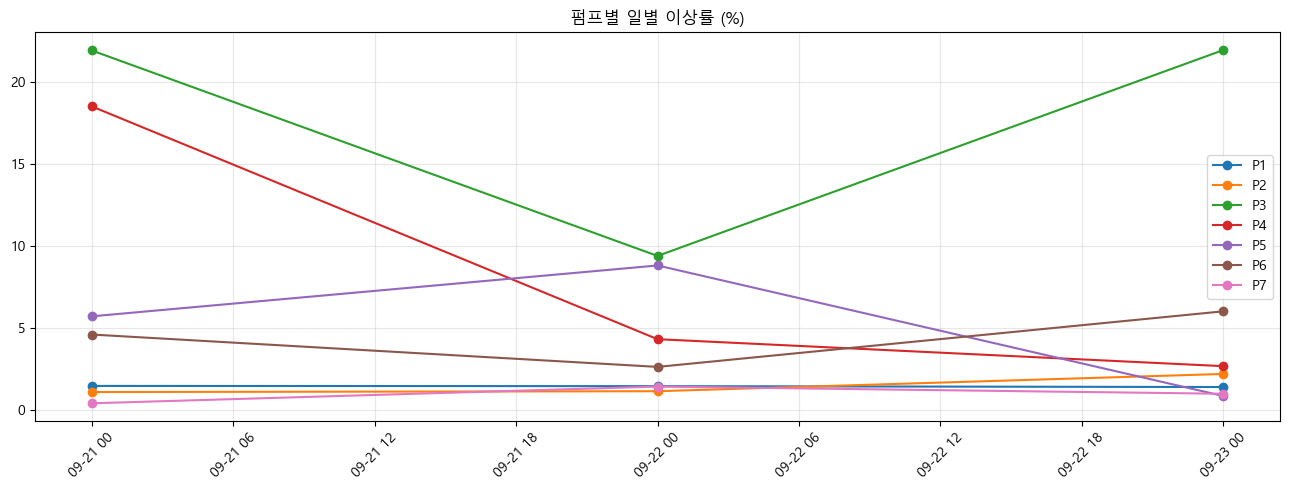

In [5]:
if results:
    fig, ax = plt.subplots(figsize=(13, 5))
    for p, daily in results.items():
        ax.plot(daily.index, daily.values, marker="o", label=p)
    ax.set_title("펌프별 일별 이상률 (%)"); ax.legend(); ax.grid(alpha=.3)
    plt.setp(ax.get_xticklabels(), rotation=45); plt.tight_layout(); plt.show()
else:
    print("완료된 펌프가 없습니다")